# Track C: VEGAS Ablation Study
## CS639 Spring 2026 — Vision-Encoder Attention Quality & Hallucination

**Hypothesis:** VEGAS (arXiv:2512.12089) assumes ViT encoder attention is a reliable signal. When ViT attention is diffuse/degraded (high entropy), VEGAS amplifies bad signals and *backfires*, producing more hallucination than baseline.

**Input (from Track A):**
- `chair_labels.csv` — baseline CHAIR scores for 500 COCO images
- `entropy_ranks.csv` — entropy quartile assignments (Q1=focused, Q4=diffuse)
- `rollout_data_complete.npz` — per-image ViT attention rollout weights (500×576)

**Output:** Hallucination rate delta (VEGAS − baseline) stratified by entropy quartile.

In [ ]:
# Install dependencies (same versions as Track A + bitsandbytes for T4 4-bit)
!pip install -q transformers==4.37.2 tokenizers==0.15.2 accelerate==0.27.2 bitsandbytes pycocotools requests tqdm

In [ ]:
import os, json, time, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from scipy.stats import chi2_contingency, spearmanr, ttest_rel
import requests
from tqdm.auto import tqdm
import torch
from transformers import LlavaForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

warnings.filterwarnings('ignore')

# GPU check
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu}  |  VRAM: {vram:.1f} GB')
    if vram < 12:
        print('WARNING: Less than 12 GB VRAM — 4-bit quantization required (already set below)')
else:
    print('WARNING: No GPU detected. Inference will be extremely slow.')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

GPU: Tesla T4  |  VRAM: 15.6 GB
Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── CONFIGURE PATHS ──────────────────────────────────────────────────────────
DRIVE_BASE  = '/content/drive/MyDrive/CS639/Project'
TRACKA_DIR  = f'{DRIVE_BASE}/TrackA_Complete_Outputs'
TRACKC_DIR  = f'{DRIVE_BASE}/TrackC_Complete_Outputs'
os.makedirs(TRACKC_DIR, exist_ok=True)
# ─────────────────────────────────────────────────────────────────────────────

required = ['chair_labels.csv', 'entropy_ranks.csv',
            'rollout_data_complete.npz', 'sampled_image_ids.json']
all_ok = True
for f in required:
    exists = os.path.exists(f'{TRACKA_DIR}/{f}')
    print(f"{'OK' if exists else 'MISSING'}: {f}")
    if not exists:
        all_ok = False
if not all_ok:
    raise FileNotFoundError('Some Track A files are missing. Check TRACKA_DIR path.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK: chair_labels.csv
OK: entropy_ranks.csv
OK: rollout_data_complete.npz
OK: sampled_image_ids.json


In [ ]:
# Load Track A outputs
chair_df   = pd.read_csv(f'{TRACKA_DIR}/chair_labels.csv')
entropy_df = pd.read_csv(f'{TRACKA_DIR}/entropy_ranks.csv')
rollout_data = np.load(f'{TRACKA_DIR}/rollout_data_complete.npz', allow_pickle=True)

rollouts_arr  = rollout_data['rollouts']    # (500, 576)
image_ids_arr = rollout_data['image_ids']   # (500,)

rollout_lookup = {int(iid): rollouts_arr[i] for i, iid in enumerate(image_ids_arr)}

with open(f'{TRACKA_DIR}/sampled_image_ids.json') as f:
    sampled_ids = [int(x) for x in json.load(f)]

# Normalise boolean column
chair_df['is_hallucinating'] = chair_df['is_hallucinating'].astype(str).str.lower().isin(['true','1'])

# Merge
merged_df = chair_df.merge(
    entropy_df[['image_id','entropy','entropy_quartile','entropy_rank']],
    on='image_id', how='inner'
).copy()
merged_df['entropy_quartile'] = merged_df['entropy_quartile'].astype(int)

print(f'Loaded {len(chair_df)} CHAIR labels, {len(entropy_df)} entropy rows')
print(f'Merged dataset: {len(merged_df)} images')
print(f'Rollout lookup: {len(rollout_lookup)} images')
print('\nQuartile counts:')
print(merged_df['entropy_quartile'].value_counts().sort_index())

Loaded 500 CHAIR labels, 500 entropy rows
Merged dataset: 500 images
Rollout lookup: 500 images

Quartile counts:
entropy_quartile
1    125
2    125
3    125
4    125
Name: count, dtype: int64


In [ ]:
# Download COCO 2017 annotations (needed for ground-truth object lists)
ANN_FILE = '/content/annotations/instances_val2017.json'
if not os.path.exists(ANN_FILE):
    print('Downloading COCO 2017 annotations (~241 MB)...')
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
    !unzip -q annotations_trainval2017.zip -d /content/
    print('Done.')
else:
    print('Annotations already present.')

# Load image metadata from annotation file
with open(ANN_FILE) as f:
    coco_meta = json.load(f)
coco_imgs = {img['id']: img for img in coco_meta['images']}
print(f'COCO metadata loaded: {len(coco_imgs)} images')

Annotations already present.
COCO metadata loaded: 5000 images


In [ ]:
# Download only the 500 sampled images (avoids the full 6 GB val set)
IMG_DIR = '/content/val2017'
os.makedirs(IMG_DIR, exist_ok=True)

missing = [iid for iid in sampled_ids
           if not os.path.exists(f'{IMG_DIR}/{coco_imgs[iid]["file_name"]}')]

if missing:
    print(f'Downloading {len(missing)} images...')
    for iid in tqdm(missing):
        img_info = coco_imgs[iid]
        dst = f'{IMG_DIR}/{img_info["file_name"]}'
        for attempt in range(3):
            try:
                r = requests.get(img_info['coco_url'], timeout=30)
                r.raise_for_status()
                with open(dst, 'wb') as f:
                    f.write(r.content)
                break
            except Exception as e:
                if attempt == 2:
                    print(f'  FAILED {iid}: {e}')
                time.sleep(1)
    print('Download complete.')
else:
    print('All images already present.')

img_path_lookup = {iid: f'{IMG_DIR}/{coco_imgs[iid]["file_name"]}'
                   for iid in sampled_ids}
print(f'Image paths ready for {len(img_path_lookup)} images')

All images already present.
Image paths ready for 500 images


In [ ]:
# Load LLaVA-1.5-7B with 4-bit quantization (safe for T4 16 GB)
print('Loading LLaVA-1.5-7B with NF4 4-bit quantization...')

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4'
)

try:
    model = LlavaForConditionalGeneration.from_pretrained(
        'llava-hf/llava-1.5-7b-hf',
        quantization_config=bnb_config,
        device_map='auto',
        attn_implementation='eager',
    )
    print('Loaded with eager attention.')
except Exception as e:
    print(f'Eager attention failed ({e}), retrying with default attention...')
    model = LlavaForConditionalGeneration.from_pretrained(
        'llava-hf/llava-1.5-7b-hf',
        quantization_config=bnb_config,
        device_map='auto',
    )

# Build processor manually — avoids both tokenizer.json format mismatch
# and the 'image_token' field in processor_config.json unknown to older LlavaProcessor
from transformers import CLIPImageProcessor, LlamaTokenizer, LlavaProcessor
image_processor = CLIPImageProcessor.from_pretrained('openai/clip-vit-large-patch14-336')
tokenizer = LlamaTokenizer.from_pretrained('llava-hf/llava-1.5-7b-hf')
processor = LlavaProcessor(image_processor=image_processor, tokenizer=tokenizer)
model.eval()

# Detect model structure: transformers <4.41 uses model.model.*, >=4.41 uses model.*
import transformers as _tf
print(f'transformers version: {_tf.__version__}')
if hasattr(model, 'model') and hasattr(model.model, 'language_model'):
    MODEL_PROJ  = model.model.multi_modal_projector   # hook target for VEGAS
    MODEL_LM    = model.model.language_model
    print('Model structure: old (model.model.*)')
else:
    MODEL_PROJ  = model.multi_modal_projector
    MODEL_LM    = model.language_model
    print('Model structure: new (model.*)')

n_layers = len(MODEL_LM.model.layers)
print(f'LLM layers: {n_layers}')
if torch.cuda.is_available():
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM used: {used:.2f} / {total:.1f} GB')

Loading LLaVA-1.5-7B with NF4 4-bit quantization...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded with eager attention.


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


transformers version: 4.37.2
Model structure: new (model.*)
LLM layers: 32
VRAM used: 8.31 / 15.6 GB


In [ ]:
# CHAIR scoring — consistent with Track A
# 80 COCO categories + synonym map
SYNONYMS = {
    'person': ['person','people','man','woman','boy','girl','child','kid','human',
               'pedestrian','rider','skater','player','athlete','guy','lady'],
    'bicycle': ['bicycle','bike','cycle'],
    'car': ['car','automobile','vehicle','sedan','suv','hatchback'],
    'motorcycle': ['motorcycle','motorbike','moped','scooter'],
    'airplane': ['airplane','plane','aircraft','jet','airliner'],
    'bus': ['bus','coach'],
    'train': ['train','locomotive'],
    'truck': ['truck','lorry','pickup'],
    'boat': ['boat','ship','vessel','sailboat','canoe','kayak','rowboat'],
    'traffic light': ['traffic light','stoplight','traffic signal'],
    'fire hydrant': ['fire hydrant','hydrant'],
    'stop sign': ['stop sign'],
    'parking meter': ['parking meter'],
    'bench': ['bench'],
    'bird': ['bird','pigeon','seagull','duck','crow','parrot','sparrow'],
    'cat': ['cat','kitten','kitty','feline'],
    'dog': ['dog','puppy','canine','hound'],
    'horse': ['horse','pony','stallion','mare','foal'],
    'sheep': ['sheep','lamb','ram','ewe'],
    'cow': ['cow','cattle','bull','calf','ox'],
    'elephant': ['elephant'],
    'bear': ['bear','grizzly','panda'],
    'zebra': ['zebra'],
    'giraffe': ['giraffe'],
    'backpack': ['backpack','rucksack','knapsack'],
    'umbrella': ['umbrella','parasol'],
    'handbag': ['handbag','purse','clutch'],
    'tie': ['tie','necktie'],
    'suitcase': ['suitcase','luggage','baggage'],
    'frisbee': ['frisbee','disc'],
    'skis': ['skis','ski'],
    'snowboard': ['snowboard'],
    'sports ball': ['ball','football','basketball','baseball','soccer ball',
                    'tennis ball','volleyball'],
    'kite': ['kite'],
    'baseball bat': ['baseball bat','bat'],
    'baseball glove': ['baseball glove','glove','mitt'],
    'skateboard': ['skateboard'],
    'surfboard': ['surfboard'],
    'tennis racket': ['tennis racket','racket','racquet'],
    'bottle': ['bottle','flask','jug'],
    'wine glass': ['wine glass','glass','goblet','wineglass'],
    'cup': ['cup','mug','tumbler'],
    'fork': ['fork'],
    'knife': ['knife','blade'],
    'spoon': ['spoon','ladle'],
    'bowl': ['bowl','dish','basin'],
    'banana': ['banana'],
    'apple': ['apple'],
    'sandwich': ['sandwich','sub','burger','hoagie'],
    'orange': ['orange','clementine','mandarin'],
    'broccoli': ['broccoli'],
    'carrot': ['carrot'],
    'hot dog': ['hot dog','hotdog','sausage','frankfurter'],
    'pizza': ['pizza'],
    'donut': ['donut','doughnut'],
    'cake': ['cake','pastry'],
    'chair': ['chair','stool'],
    'couch': ['couch','sofa','settee','loveseat'],
    'potted plant': ['potted plant','plant','houseplant','flower pot'],
    'bed': ['bed','mattress','cot'],
    'dining table': ['dining table','table','desk','countertop'],
    'toilet': ['toilet','commode'],
    'tv': ['tv','television','monitor','screen','display'],
    'laptop': ['laptop','computer','notebook computer'],
    'mouse': ['mouse','computer mouse'],
    'remote': ['remote','remote control'],
    'keyboard': ['keyboard'],
    'cell phone': ['cell phone','phone','smartphone','mobile'],
    'microwave': ['microwave','microwave oven'],
    'oven': ['oven','stove'],
    'toaster': ['toaster'],
    'sink': ['sink','basin'],
    'refrigerator': ['refrigerator','fridge'],
    'book': ['book','novel','textbook'],
    'clock': ['clock','watch','timepiece'],
    'vase': ['vase','urn'],
    'scissors': ['scissors','shears'],
    'teddy bear': ['teddy bear','stuffed animal','plush toy','stuffed toy','toy bear'],
    'hair drier': ['hair drier','hair dryer','dryer','blow dryer'],
    'toothbrush': ['toothbrush'],
}

# Build reverse lookup: phrase → canonical COCO object name
WORD_TO_OBJ = {}
for obj, syns in SYNONYMS.items():
    for s in syns:
        WORD_TO_OBJ[s] = obj

# Sort by length descending so multi-word phrases match before substrings
_sorted_phrases = sorted(WORD_TO_OBJ.keys(), key=len, reverse=True)

def extract_objects(caption):
    cap = caption.lower()
    found = set()
    for phrase in _sorted_phrases:
        if phrase in cap:
            found.add(WORD_TO_OBJ[phrase])
    return found

def compute_chair_i(caption, gt_objects_str):
    """Returns (chair_i, list_of_hallucinated_objects)."""
    if pd.isna(gt_objects_str) or str(gt_objects_str).strip() == '':
        gt = set()
    else:
        gt = set(str(gt_objects_str).split('|'))
    mentioned = extract_objects(caption)
    if not mentioned:
        return 0.0, []
    hallucinated = mentioned - gt
    return len(hallucinated) / len(mentioned), list(hallucinated)

# Quick sanity check
test_cap = 'A dog and a bicycle are parked on the street.'
test_gt  = 'dog|bench'
ci, hall = compute_chair_i(test_cap, test_gt)
print(f'Sanity check — CHAIR_i={ci:.2f}, hallucinated={hall}')  # expect bicycle~0.5

Sanity check — CHAIR_i=0.50, hallucinated=['bicycle']


In [ ]:
# VEGAS implementation
# Hook on the multi_modal_projector output and scale each visual token embedding
# by its ViT attention rollout weight.
# Larger scale → larger key vector → higher attention score from LLM queries.
#
# Low-entropy rollout (Q1): scale is focused → LLM attends to correct object patch.
# High-entropy rollout (Q4): scale is near-uniform → amplifies background noise → backfire.

ALPHA = 3.0
PROMPT = ('USER: <image>\n'
          'Describe everything you see in this image in detail, '
          'listing all objects, people, and animals visible.\nASSISTANT:')


def make_vegas_hook(rollout_weights, alpha=ALPHA):
    """Creates a forward hook for the multi_modal_projector."""
    rw = torch.tensor(rollout_weights, dtype=torch.float32)
    rw = (rw - rw.min()) / (rw.max() - rw.min() + 1e-8)  # normalize 0→1
    scale = 1.0 + alpha * rw                               # (576,) in [1, 1+alpha]

    def hook(module, inp, output):
        # output: (1, num_patches, lm_hidden_dim)
        n = output.shape[1]
        s = scale[:n].to(output.device).to(output.dtype)
        return output * s.unsqueeze(0).unsqueeze(-1)

    return hook


def run_vegas(image, rollout_weights, alpha=ALPHA):
    """Run LLaVA with VEGAS hook active. Returns caption string."""
    hook_fn = make_vegas_hook(rollout_weights, alpha=alpha)
    # MODEL_PROJ is set in the model-loading cell (version-agnostic)
    handle = MODEL_PROJ.register_forward_hook(hook_fn)
    try:
        inputs = processor(text=PROMPT, images=image, return_tensors='pt')
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        if 'pixel_values' in inputs:
            inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=200,
                do_sample=False,
                temperature=None,
                top_p=None,
            )
        prompt_len = inputs['input_ids'].shape[1]
        return processor.decode(out[0][prompt_len:], skip_special_tokens=True).strip()
    finally:
        handle.remove()


# Smoke test on one image
test_row    = merged_df.iloc[0]
test_id     = int(test_row['image_id'])
test_img    = Image.open(img_path_lookup[test_id]).convert('RGB')
test_rollout = rollout_lookup[test_id]

print('Running VEGAS smoke test...')
vegas_cap = run_vegas(test_img, test_rollout)
ci, _     = compute_chair_i(vegas_cap, test_row.get('gt_objects', ''))
print(f'Image {test_id}  Q{test_row["entropy_quartile"]}  entropy={test_row["entropy"]:.4f}')
print(f'Baseline: {str(test_row["caption"])[:120]}')
print(f'VEGAS:    {vegas_cap[:120]}')
print(f'Baseline CHAIR_i={test_row["chair_i"]:.4f}  VEGAS CHAIR_i={ci:.4f}')
print('Smoke test passed.')

Running VEGAS smoke test...
Image 776  Q1  entropy=6.2955
Baseline: The image features a group of teddy bears, with some of them sitting on top of each other. There are at least five teddy
VEGAS:    The image features a group of teddy bears, with some of them sitting on a bed. There are at least five teddy bears in th
Baseline CHAIR_i=0.5000  VEGAS CHAIR_i=0.6000
Smoke test passed.


In [ ]:
# Main VEGAS inference loop — 500 images with checkpointing
CKPT = f'{TRACKC_DIR}/vegas_labels_checkpoint.csv'
EVERY = 25

# Resume from checkpoint if it exists
if os.path.exists(CKPT):
    done_df  = pd.read_csv(CKPT)
    done_ids = set(done_df['image_id'].astype(int))
    results  = done_df.to_dict('records')
    print(f'Resuming: {len(done_ids)}/500 already done')
else:
    done_ids = set()
    results  = []
    print('Starting fresh inference...')

todo = merged_df[~merged_df['image_id'].isin(done_ids)].reset_index(drop=True)
print(f'Remaining: {len(todo)} images')

t0 = time.time()

for idx, row in todo.iterrows():
    img_id = int(row['image_id'])
    path   = img_path_lookup.get(img_id)
    if path is None or not os.path.exists(path):
        print(f'  SKIP {img_id}: image file not found')
        continue

    image   = Image.open(path).convert('RGB')
    rollout = rollout_lookup[img_id]

    try:
        caption = run_vegas(image, rollout)
    except Exception as e:
        print(f'  ERROR {img_id}: {e}')
        caption = ''

    chair_i, hall_objs = compute_chair_i(caption, row.get('gt_objects', ''))

    results.append({
        'image_id':                   img_id,
        'file_name':                  row['file_name'],
        'entropy':                    row['entropy'],
        'entropy_quartile':           int(row['entropy_quartile']),
        'gt_objects':                 row.get('gt_objects', ''),
        'baseline_chair_i':           float(row['chair_i']),
        'baseline_is_hallucinating':  int(bool(row['is_hallucinating'])),
        'vegas_caption':              caption,
        'vegas_chair_i':              float(chair_i),
        'vegas_is_hallucinating':     int(chair_i > 0),
        'vegas_hallucinated_objects': '|'.join(hall_objs),
    })

    n_done = len(results)
    if n_done % EVERY == 0:
        pd.DataFrame(results).to_csv(CKPT, index=False)
        elapsed = time.time() - t0
        rate    = n_done / elapsed
        eta     = (500 - n_done) / rate if rate > 0 else 0
        print(f'[{n_done}/500]  {elapsed/60:.1f} min elapsed  |  ETA {eta/60:.1f} min')

vegas_df = pd.DataFrame(results)
out_path = f'{TRACKC_DIR}/vegas_chair_labels.csv'
vegas_df.to_csv(out_path, index=False)
print(f'\nSaved {len(vegas_df)} rows to {out_path}')

Starting fresh inference...
Remaining: 500 images
[25/500]  9.1 min elapsed  |  ETA 172.4 min
[50/500]  18.7 min elapsed  |  ETA 168.2 min
[75/500]  28.3 min elapsed  |  ETA 160.5 min
[100/500]  37.3 min elapsed  |  ETA 149.1 min
[125/500]  46.9 min elapsed  |  ETA 140.7 min
[150/500]  55.9 min elapsed  |  ETA 130.4 min
[175/500]  65.0 min elapsed  |  ETA 120.7 min
[200/500]  73.9 min elapsed  |  ETA 110.8 min
[225/500]  82.5 min elapsed  |  ETA 100.8 min
[250/500]  92.1 min elapsed  |  ETA 92.1 min
[275/500]  100.9 min elapsed  |  ETA 82.5 min
[300/500]  110.1 min elapsed  |  ETA 73.4 min
[325/500]  118.9 min elapsed  |  ETA 64.0 min
[350/500]  128.8 min elapsed  |  ETA 55.2 min
[375/500]  137.6 min elapsed  |  ETA 45.9 min
[400/500]  146.2 min elapsed  |  ETA 36.5 min
[425/500]  155.2 min elapsed  |  ETA 27.4 min
[450/500]  164.0 min elapsed  |  ETA 18.2 min
[475/500]  172.6 min elapsed  |  ETA 9.1 min
[500/500]  181.8 min elapsed  |  ETA 0.0 min

Saved 500 rows to /content/drive/MyD

In [ ]:
# Quick results check
print('='*60)
print('RESULTS OVERVIEW')
print('='*60)
print(f'Total images processed: {len(vegas_df)}')
print(f'Baseline hall rate: {vegas_df["baseline_is_hallucinating"].mean():.3f}')
print(f'VEGAS    hall rate: {vegas_df["vegas_is_hallucinating"].mean():.3f}')
print(f'Baseline mean CHAIR_i: {vegas_df["baseline_chair_i"].mean():.4f}')
print(f'VEGAS    mean CHAIR_i: {vegas_df["vegas_chair_i"].mean():.4f}')
print()
for q in [1,2,3,4]:
    s = vegas_df[vegas_df['entropy_quartile']==q]
    delta = s['vegas_chair_i'].mean() - s['baseline_chair_i'].mean()
    print(f'  Q{q} (n={len(s)}): baseline={s["baseline_chair_i"].mean():.4f}  '
          f'VEGAS={s["vegas_chair_i"].mean():.4f}  delta={delta:+.4f}')

RESULTS OVERVIEW
Total images processed: 500
Baseline hall rate: 0.658
VEGAS    hall rate: 0.888
Baseline mean CHAIR_i: 0.3186
VEGAS    mean CHAIR_i: 0.4763

  Q1 (n=125): baseline=0.3057  VEGAS=0.4566  delta=+0.1509
  Q2 (n=125): baseline=0.3256  VEGAS=0.4573  delta=+0.1316
  Q3 (n=125): baseline=0.3196  VEGAS=0.5132  delta=+0.1936
  Q4 (n=125): baseline=0.3234  VEGAS=0.4779  delta=+0.1545


In [ ]:
# Statistical analysis
vegas_df['chair_delta'] = vegas_df['vegas_chair_i'] - vegas_df['baseline_chair_i']

print('='*72)
print('TRACK C — VEGAS ABLATION: STATISTICAL RESULTS')
print('='*72)

summary_rows = []
for q in [1,2,3,4]:
    s = vegas_df[vegas_df['entropy_quartile']==q].copy()
    n = len(s)

    base_rate  = s['baseline_is_hallucinating'].mean()
    vegas_rate = s['vegas_is_hallucinating'].mean()
    delta_rate = vegas_rate - base_rate

    base_chair  = s['baseline_chair_i'].mean()
    vegas_chair = s['vegas_chair_i'].mean()
    delta_chair = vegas_chair - base_chair

    bh = int(s['baseline_is_hallucinating'].sum())
    vh = int(s['vegas_is_hallucinating'].sum())
    chi2, chi_p, _, _ = chi2_contingency([[bh, n-bh],[vh, n-vh]])

    _, t_p = ttest_rel(s['vegas_chair_i'], s['baseline_chair_i'])

    rho, rho_p = spearmanr(s['entropy'], s['chair_delta'])

    verdict = 'HELPS' if delta_chair < -0.01 else ('HURTS' if delta_chair > 0.01 else 'NEUTRAL')

    summary_rows.append({
        'Quartile':          f'Q{q}',
        'N':                 n,
        'Entropy range':     f'[{s["entropy"].min():.3f},{s["entropy"].max():.3f}]',
        'Baseline hall%':    f'{base_rate:.3f}',
        'VEGAS hall%':       f'{vegas_rate:.3f}',
        'Delta hall%':       f'{delta_rate:+.3f}',
        'Baseline CHAIR_i':  f'{base_chair:.4f}',
        'VEGAS CHAIR_i':     f'{vegas_chair:.4f}',
        'Delta CHAIR_i':     f'{delta_chair:+.4f}',
        'chi2 p':            f'{chi_p:.4f}',
        't-test p':          f'{t_p:.4f}',
        'Spearman rho':      f'{rho:.3f}',
        'Verdict':           verdict,
    })

    print(f'\nQ{q}  (n={n}, entropy=[{s["entropy"].min():.4f},{s["entropy"].max():.4f}])')
    print(f'  Hall rate: {base_rate:.3f} → {vegas_rate:.3f}  (delta={delta_rate:+.3f})')
    print(f'  CHAIR_i:   {base_chair:.4f} → {vegas_chair:.4f}  (delta={delta_chair:+.4f})')
    print(f'  chi2 p={chi_p:.4f}  t-test p={t_p:.4f}  Spearman rho={rho:.3f}')
    print(f'  Verdict: {verdict}')

ablation_df = pd.DataFrame(summary_rows)
ablation_df.to_csv(f'{TRACKC_DIR}/ablation_results_table.csv', index=False)
print(f'\nAblation table saved.')
print(ablation_df.to_string(index=False))

# Overall Spearman
rho_all, p_all = spearmanr(vegas_df['entropy'], vegas_df['chair_delta'])
print(f'\nOverall Spearman rho(entropy, CHAIR_delta) = {rho_all:.4f}  p={p_all:.4f}')
print('Positive rho supports hypothesis: VEGAS hurts more on high-entropy images.')

TRACK C — VEGAS ABLATION: STATISTICAL RESULTS

Q1  (n=125, entropy=[6.2782,6.3141])
  Hall rate: 0.616 → 0.808  (delta=+0.192)
  CHAIR_i:   0.3057 → 0.4566  (delta=+0.1509)
  chi2 p=0.0013  t-test p=0.0000  Spearman rho=-0.015
  Verdict: HURTS

Q2  (n=125, entropy=[6.3141,6.3219])
  Hall rate: 0.688 → 0.920  (delta=+0.232)
  CHAIR_i:   0.3256 → 0.4573  (delta=+0.1316)
  chi2 p=0.0000  t-test p=0.0000  Spearman rho=0.070
  Verdict: HURTS

Q3  (n=125, entropy=[6.3219,6.3288])
  Hall rate: 0.688 → 0.936  (delta=+0.248)
  CHAIR_i:   0.3196 → 0.5132  (delta=+0.1936)
  chi2 p=0.0000  t-test p=0.0000  Spearman rho=0.096
  Verdict: HURTS

Q4  (n=125, entropy=[6.3289,6.3461])
  Hall rate: 0.640 → 0.888  (delta=+0.248)
  CHAIR_i:   0.3234 → 0.4779  (delta=+0.1545)
  chi2 p=0.0000  t-test p=0.0000  Spearman rho=-0.013
  Verdict: HURTS

Ablation table saved.
Quartile   N Entropy range Baseline hall% VEGAS hall% Delta hall% Baseline CHAIR_i VEGAS CHAIR_i Delta CHAIR_i chi2 p t-test p Spearman rho V

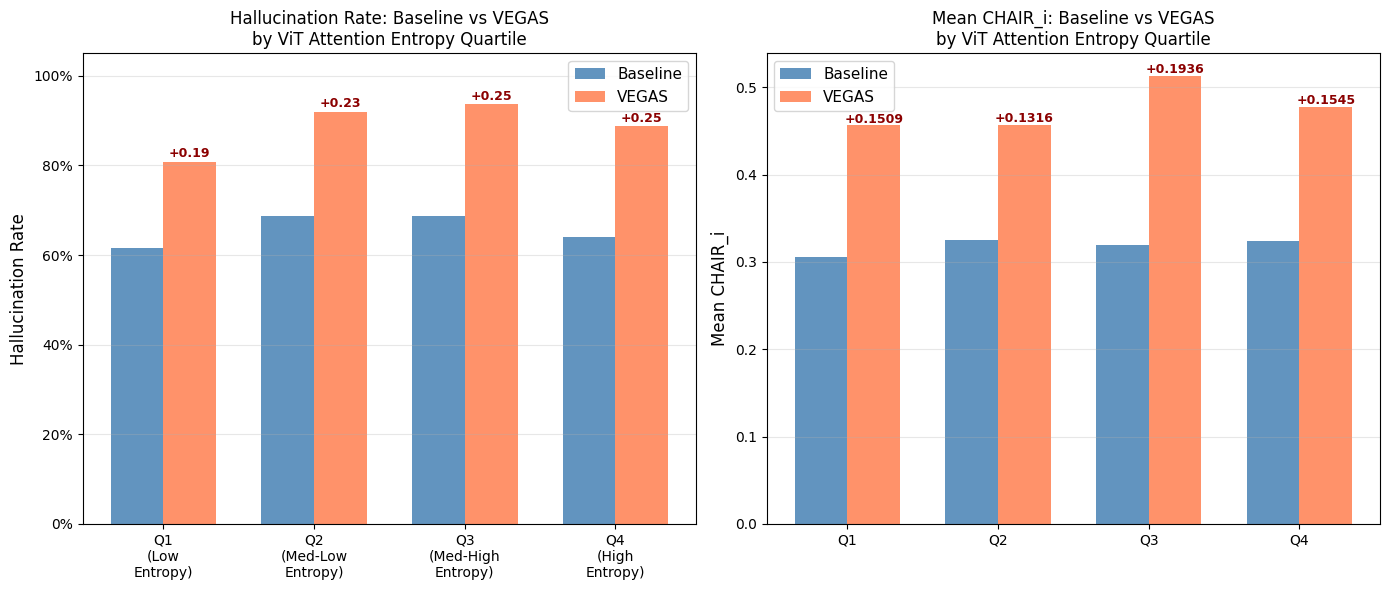

Figure 1 saved.


In [ ]:
# Figure 1 — Baseline vs VEGAS hallucination rate and CHAIR_i by quartile
quartiles   = [1,2,3,4]
x           = np.arange(4)
w           = 0.35

base_rates  = [vegas_df[vegas_df['entropy_quartile']==q]['baseline_is_hallucinating'].mean() for q in quartiles]
vegas_rates = [vegas_df[vegas_df['entropy_quartile']==q]['vegas_is_hallucinating'].mean()    for q in quartiles]
base_chair  = [vegas_df[vegas_df['entropy_quartile']==q]['baseline_chair_i'].mean()          for q in quartiles]
vegas_chair = [vegas_df[vegas_df['entropy_quartile']==q]['vegas_chair_i'].mean()             for q in quartiles]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left — hallucination rate
b1 = ax1.bar(x - w/2, base_rates,  w, label='Baseline', color='steelblue', alpha=0.85)
b2 = ax1.bar(x + w/2, vegas_rates, w, label='VEGAS',    color='coral',     alpha=0.85)
for xi, (br, vr) in enumerate(zip(base_rates, vegas_rates)):
    d = vr - br
    ax1.annotate(f'{d:+.2f}', xy=(x[xi]+w/2, vr+0.01), ha='center', fontsize=9,
                 color='darkgreen' if d < 0 else 'darkred', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Q{q}\n({["Low","Med-Low","Med-High","High"][q-1]}\nEntropy)' for q in quartiles])
ax1.set_ylabel('Hallucination Rate', fontsize=12)
ax1.set_title('Hallucination Rate: Baseline vs VEGAS\nby ViT Attention Entropy Quartile', fontsize=12)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
ax1.grid(axis='y', alpha=0.3)

# Right — mean CHAIR_i
ax2.bar(x - w/2, base_chair,  w, label='Baseline', color='steelblue', alpha=0.85)
ax2.bar(x + w/2, vegas_chair, w, label='VEGAS',    color='coral',     alpha=0.85)
for xi, (bc, vc) in enumerate(zip(base_chair, vegas_chair)):
    d = vc - bc
    ax2.annotate(f'{d:+.4f}', xy=(x[xi]+w/2, vc+0.003), ha='center', fontsize=9,
                 color='darkgreen' if d < 0 else 'darkred', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Q{q}' for q in quartiles])
ax2.set_ylabel('Mean CHAIR_i', fontsize=12)
ax2.set_title('Mean CHAIR_i: Baseline vs VEGAS\nby ViT Attention Entropy Quartile', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{TRACKC_DIR}/figure_vegas_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

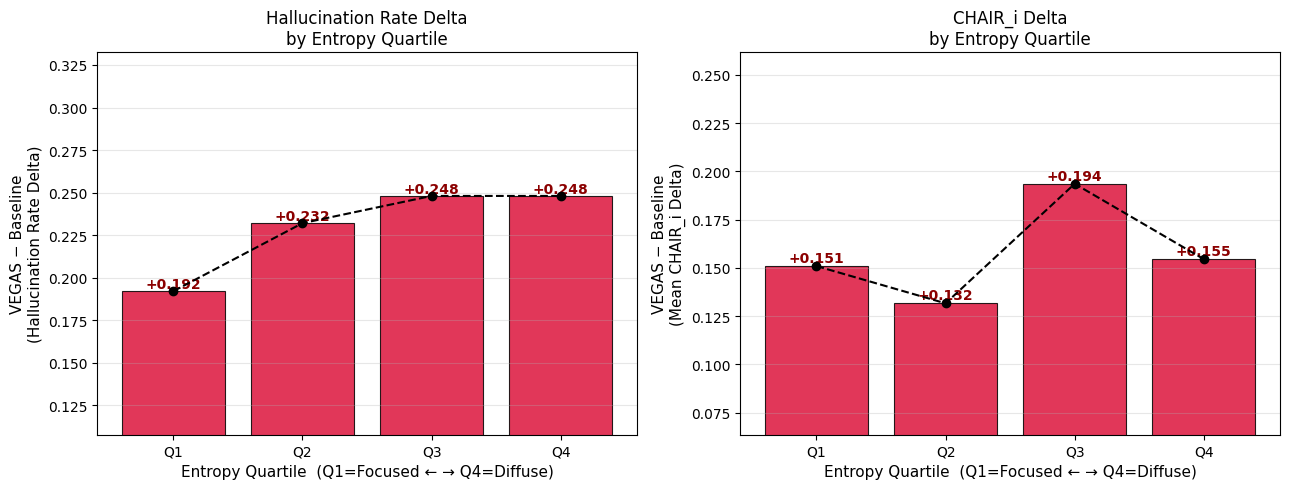

Figure 2 saved.


In [ ]:
# Figure 2 — VEGAS delta across quartiles (bar + line)
deltas_rate  = [v-b for v,b in zip(vegas_rates, base_rates)]
deltas_chair = [v-b for v,b in zip(vegas_chair, base_chair)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors_r = ['seagreen' if d < 0 else 'crimson' for d in deltas_rate]
colors_c = ['seagreen' if d < 0 else 'crimson' for d in deltas_chair]

for ax, deltas, colors, ylabel, title in [
    (ax1, deltas_rate,  colors_r, 'VEGAS − Baseline\n(Hallucination Rate Delta)',
     'Hallucination Rate Delta\nby Entropy Quartile'),
    (ax2, deltas_chair, colors_c, 'VEGAS − Baseline\n(Mean CHAIR_i Delta)',
     'CHAIR_i Delta\nby Entropy Quartile'),
]:
    ax.bar(quartiles, deltas, color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
    ax.plot(quartiles, deltas, 'ko--', linewidth=1.5, markersize=6, zorder=5)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xticks(quartiles)
    ax.set_xticklabels([f'Q{q}' for q in quartiles])
    ax.set_xlabel('Entropy Quartile  (Q1=Focused ← → Q4=Diffuse)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    for q, d in zip(quartiles, deltas):
        ax.text(q, d + (0.002 if d >= 0 else -0.003), f'{d:+.3f}',
                ha='center', fontsize=10, fontweight='bold',
                color='darkgreen' if d < 0 else 'darkred')
    ax.grid(axis='y', alpha=0.3)
    ypad = max(abs(min(deltas)), abs(max(deltas))) * 0.3 + 0.01
    ax.set_ylim(min(deltas) - ypad, max(deltas) + ypad)

plt.tight_layout()
plt.savefig(f'{TRACKC_DIR}/figure_vegas_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

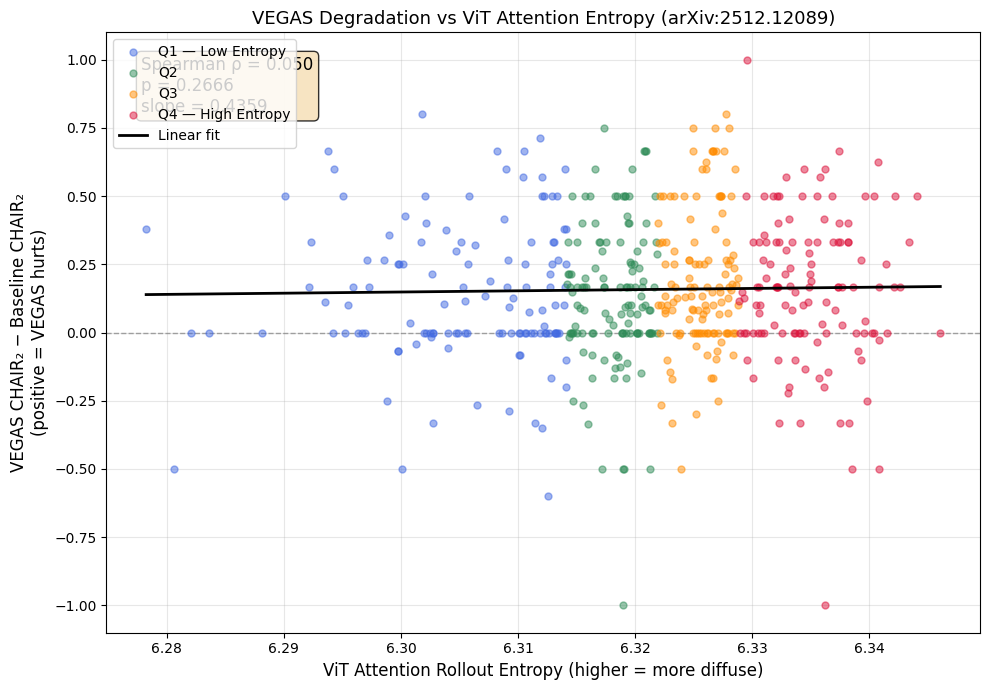

Figure 3 saved.


In [ ]:
# Figure 3 — Scatter: entropy vs CHAIR delta (coloured by quartile)
q_colors = {1:'royalblue', 2:'seagreen', 3:'darkorange', 4:'crimson'}
q_labels  = {1:'Q1 — Low Entropy', 2:'Q2', 3:'Q3', 4:'Q4 — High Entropy'}

fig, ax = plt.subplots(figsize=(10, 7))

for q in [1,2,3,4]:
    s = vegas_df[vegas_df['entropy_quartile']==q]
    ax.scatter(s['entropy'], s['chair_delta'],
               alpha=0.5, s=25, color=q_colors[q], label=q_labels[q], zorder=3)

# Linear regression line
x_vals = vegas_df['entropy'].values
y_vals = vegas_df['chair_delta'].values
slope, intercept = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
ax.plot(x_line, slope*x_line + intercept, 'k-', linewidth=2, label='Linear fit', zorder=5)

# Annotation
ax.text(0.04, 0.96,
        f'Spearman \u03c1 = {rho_all:.3f}\np = {p_all:.4f}\n'
        f'slope = {slope:.4f}',
        transform=ax.transAxes, fontsize=12, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.axhline(0, color='gray', linewidth=1.0, linestyle='--', alpha=0.7)
ax.set_xlabel('ViT Attention Rollout Entropy (higher = more diffuse)', fontsize=12)
ax.set_ylabel('VEGAS CHAIR\u2082 \u2212 Baseline CHAIR\u2082\n(positive = VEGAS hurts)', fontsize=12)
ax.set_title('VEGAS Degradation vs ViT Attention Entropy (arXiv:2512.12089)', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{TRACKC_DIR}/figure_vegas_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

In [ ]:
# Final summary
print('='*70)
print('TRACK C COMPLETE')
print('='*70)
print(f'\nOutput folder: {TRACKC_DIR}')
for fname in ['vegas_chair_labels.csv','ablation_results_table.csv',
              'figure_vegas_comparison.png','figure_vegas_delta.png',
              'figure_vegas_scatter.png']:
    exists = os.path.exists(f'{TRACKC_DIR}/{fname}')
    print(f"  {'OK' if exists else 'MISSING'}: {fname}")

print(f'\nOverall Spearman rho(entropy, delta) = {rho_all:.4f}  p={p_all:.4f}')
if rho_all > 0.05:
    finding = 'SUPPORTS hypothesis: VEGAS degrades more on high-entropy (diffuse) images.'
elif rho_all < -0.05:
    finding = 'CONTRADICTS hypothesis: VEGAS helps regardless of entropy.'
else:
    finding = 'NULL result: entropy does not predict VEGAS effectiveness.'
print(f'Finding: {finding}')
print('\nAblation table (for the report):')
print(ablation_df.to_string(index=False))

TRACK C COMPLETE

Output folder: /content/drive/MyDrive/CS639/Project/TrackC_Complete_Outputs
  OK: vegas_chair_labels.csv
  OK: ablation_results_table.csv
  OK: figure_vegas_comparison.png
  OK: figure_vegas_delta.png
  OK: figure_vegas_scatter.png

Overall Spearman rho(entropy, delta) = 0.0498  p=0.2666
Finding: NULL result: entropy does not predict VEGAS effectiveness.

Ablation table (for the report):
Quartile   N Entropy range Baseline hall% VEGAS hall% Delta hall% Baseline CHAIR_i VEGAS CHAIR_i Delta CHAIR_i chi2 p t-test p Spearman rho Verdict
      Q1 125 [6.278,6.314]          0.616       0.808      +0.192           0.3057        0.4566       +0.1509 0.0013   0.0000       -0.015   HURTS
      Q2 125 [6.314,6.322]          0.688       0.920      +0.232           0.3256        0.4573       +0.1316 0.0000   0.0000        0.070   HURTS
      Q3 125 [6.322,6.329]          0.688       0.936      +0.248           0.3196        0.5132       +0.1936 0.0000   0.0000        0.096   HURTS